# Proof-of-Concept: Chromatin optimal kappa algorithm, replicate 1

In this notebook, we examine intergenic regions and daughter-specific genes. The goal here is to show that we are indeed identifying daughter-specific changes, in the DSE1-4 genes. While appropriately minimizing false positive effects in control intergenic regions where there should be little change, and little differences between the mother and daughter branches.

We aim to find an optimal kappa value that maximizes signal (of DSE chromatin in DG1 compared to CG1) and minimizes false positives (of intergenic CG1/DG1 differences).

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.utils import mkdir_safe
from src.chromatin_deconvolution_solver import plot_example_fits
from src.chromatin_deconvolution_solver import plot_branches
from src.chromatin_model import plot_prediction
from src.geneset import get_deconvolved_geneset
from src.sgd import get_orfname
from src.RealDataReplication import read_n_fr_b
from src.chromatin_deconvolution_solver import subset_select_highest_G_indices


In [3]:
from src.chromatin_model import ChromatinModel
from src.config import load_default_chrom_configs

config1, config2 = load_default_chrom_configs('distinct')
chromatin_model1 = ChromatinModel(config1)


todo: Loading testing config from replication deconvolution


In [870]:
from src.sgd import get_orfname
from src.sgd import read_nondubious_genes_dataset

genes = read_nondubious_genes_dataset()
orfname = get_orfname('SSK22')

gene = genes.loc[orfname]
tss = gene.TSS
chrom = gene.chr
mnase_span = tss-200, tss+200

orf_plotter = load_default_orf_plotter()
orf_plotter.set_span_chrom(mnase_span, chrom)
orf_plotter.plot_orf_annotations(axs[0])

chromatin_model = ChromatinModel(config1)
chromatin_model.load_mnase_span(chrom=chrom, mnase_span=mnase_span)

Loading chromosome reads: 3
Applying a normalization for length distribution


In [871]:
from src.chromatin_gamma_search import ChromatinFindOptimalGamma
from src.chromatin_deconvolution_solver import ChromatinDeconvolveSolver

In [872]:
from src.chromatin_deconvolution_solver import dummy_N_frep_b, \
    subset_select_highest_G_indices

N, frep, b = dummy_N_frep_b(config1)
G_values, highest_Gs = subset_select_highest_G_indices(chromatin_model.G)
chromatin_solver = ChromatinDeconvolveSolver(config1, G_values, N, b, frep)

Completed. - 00:00:54.851


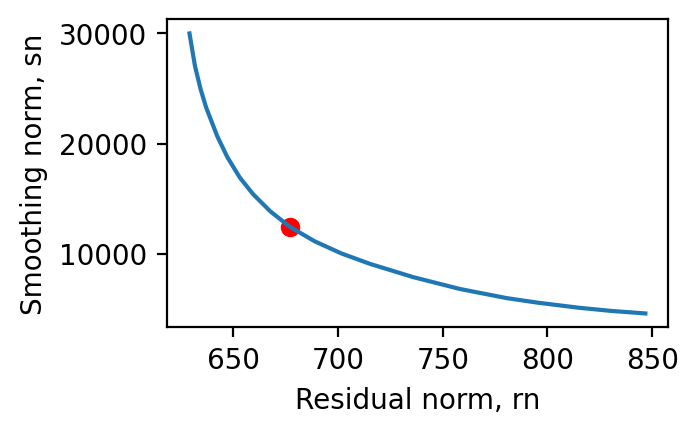

In [887]:
chrom_find_gamma = ChromatinFindOptimalGamma(chromatin_solver, gamma_min=0.001,
                                            gamma_max=1, verbose=False,
                                            kappa=0.01)
chrom_find_gamma.find_optimal_gamma()

In [888]:
optimal_gamma = chrom_find_gamma.gamma_optimizer.optimal_gamma
print("Initial gamma to begin kappa sweep: ", optimal_gamma)

Initial gamma to begin kappa sweep:  0.00763959944903568


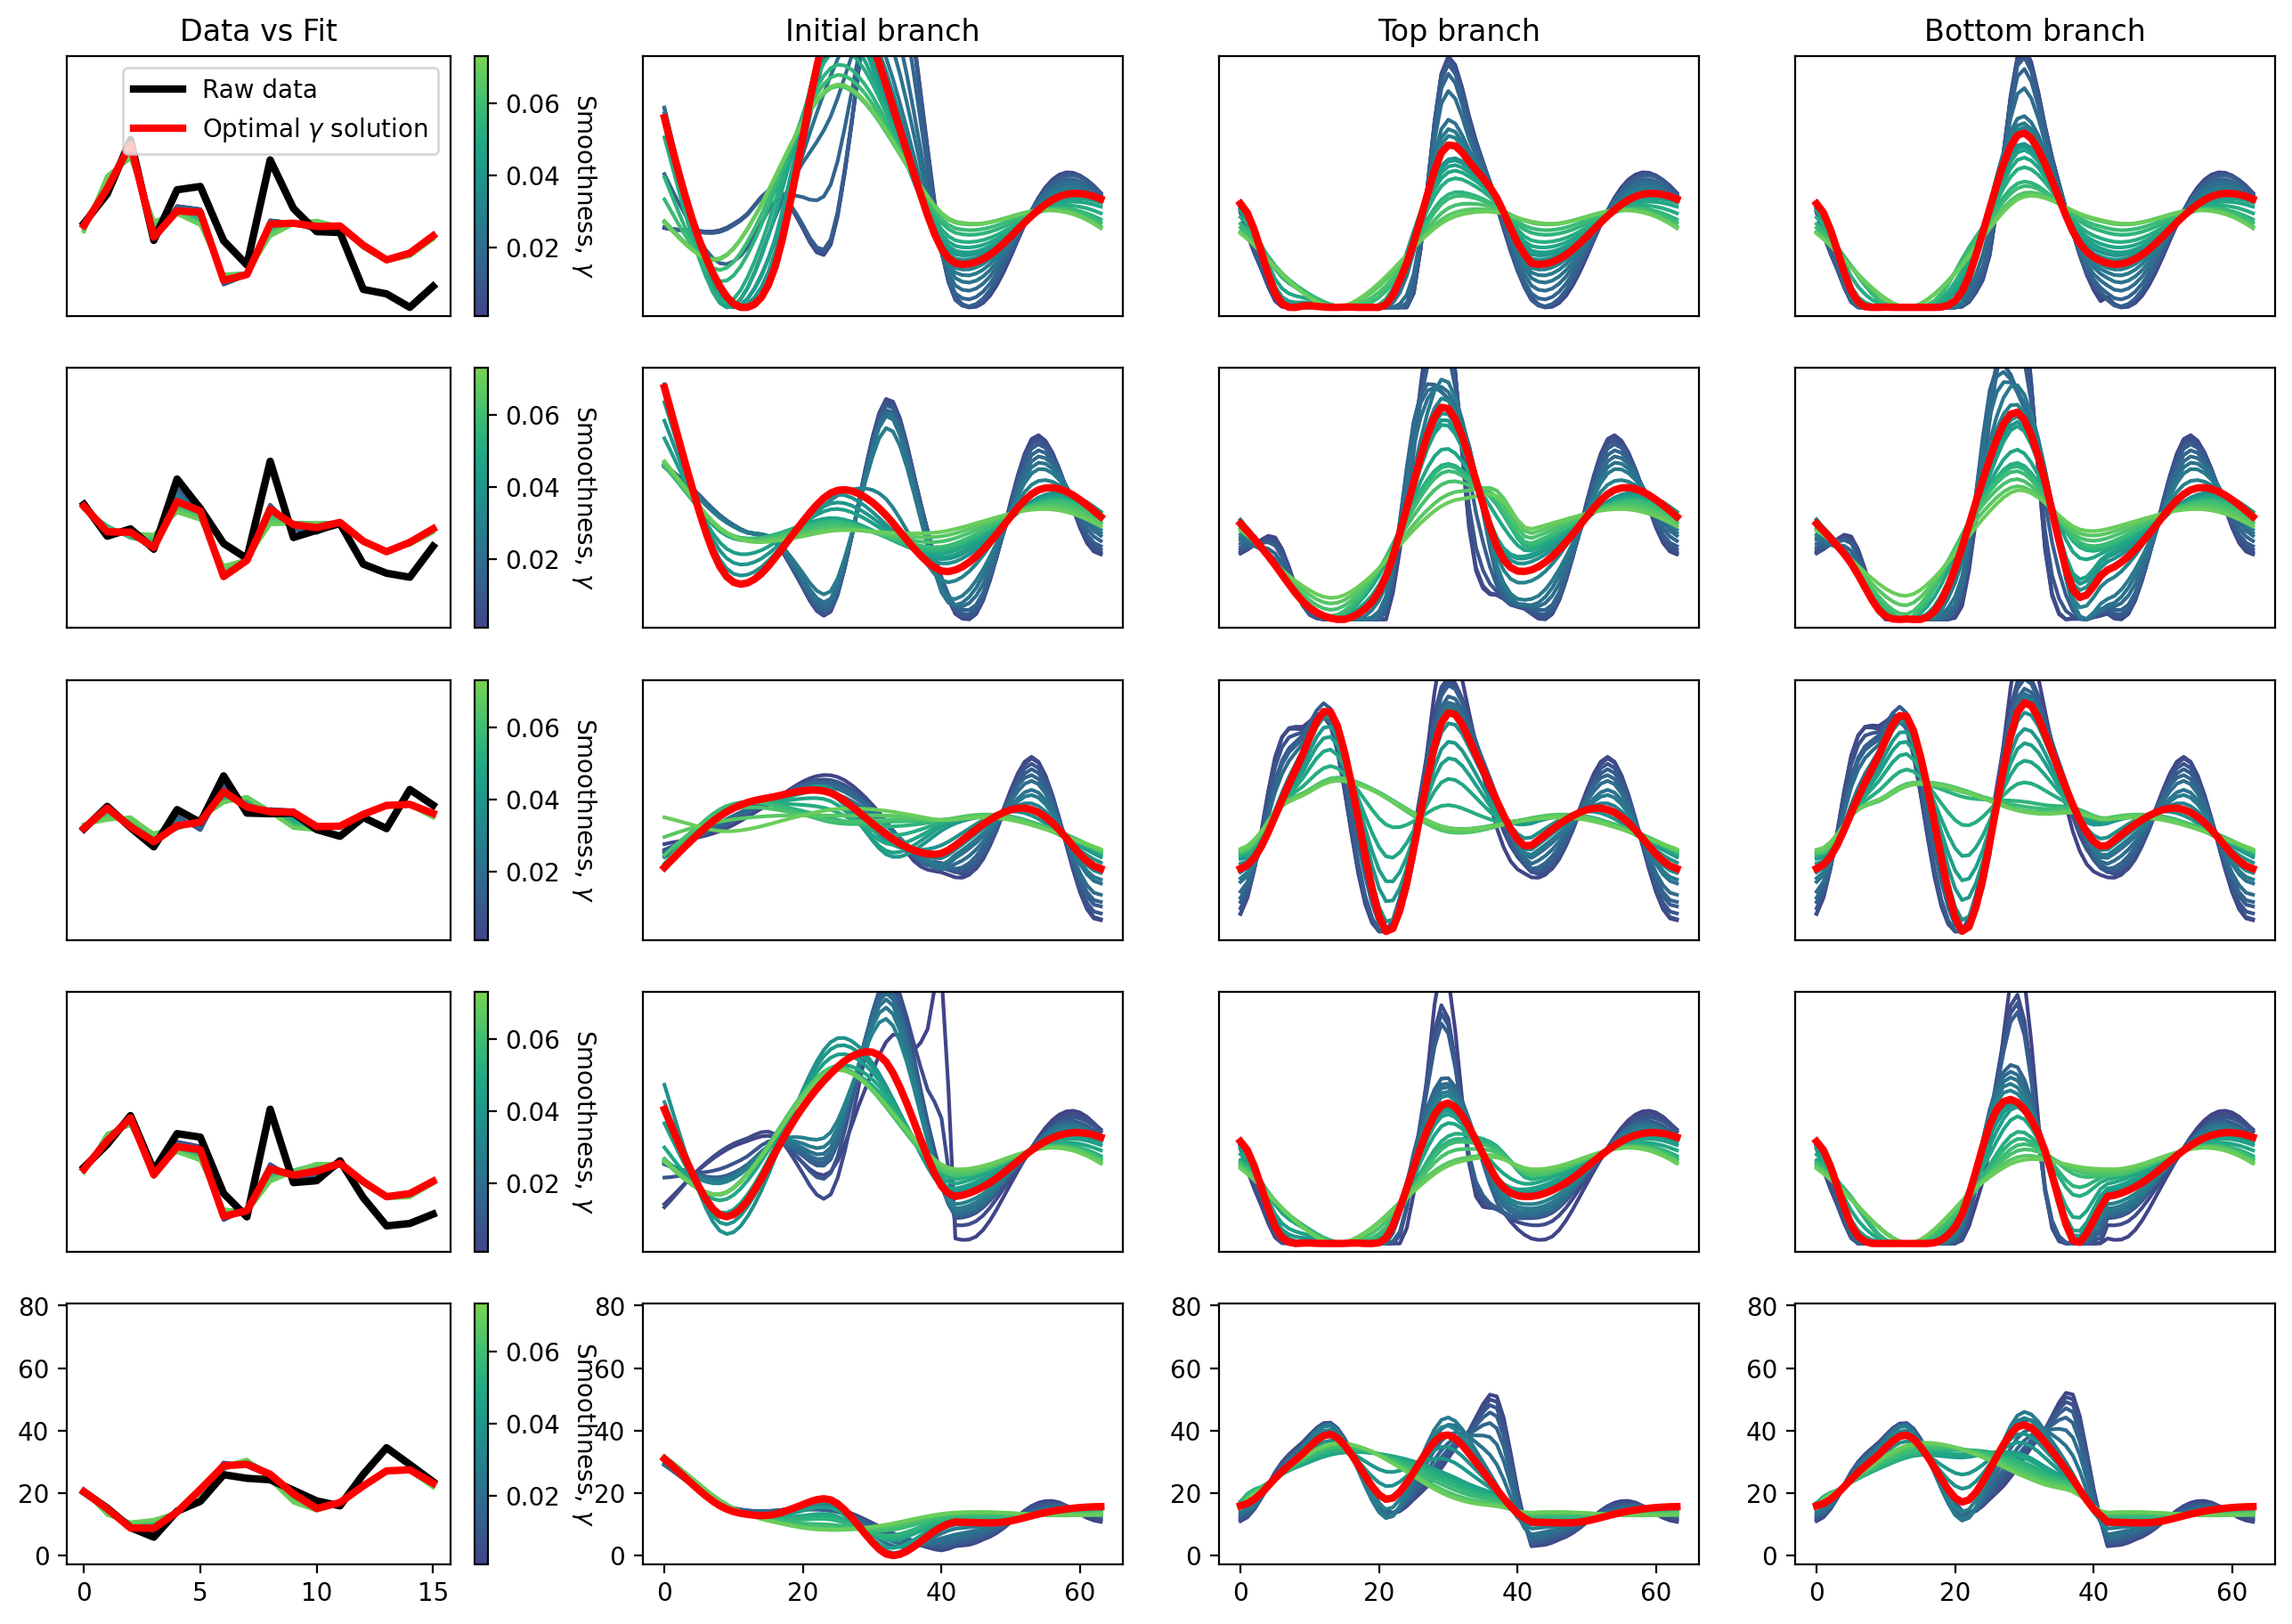

In [889]:
_ = chrom_find_gamma.plot_gamma_sweep()

Next, we are interested in DSE1 and SSK22as our initial signal to noise genes. 

Let's look at the chromatin for each of these, we are looking in the raw data for where
the signal should be for DSE1.

In [903]:
genes = get_deconvolved_geneset()

genes[genes['gene'] == 'RPL2A']

,gene,chr,cat,start,stop,strand,classification,length,TSS,PAS,manually_curated,promoter_start,promoter_end,gene_body_start,gene_body_end
orf_name,,,,,,,,,,,,,,,
YFR031C-A,RPL2A,6,gene,220507,221418,-,Verified,911,221479,220349,False,221479.0,221779.0,220979.0,221479.0


In [904]:
from src.timer import Timer

gene_names = ['SSK22', 'DSE1', 'DSE2', 'CLB2', 'MCM6',
              'RPL1A', 'RPL2A', 'DSE3', 'DSE4', 'CLN2']
timer = Timer()

gamma = 0.0076
kappa = 0.001

for gene_name in gene_names:
    print(gene_name)
    
    try:
        chromatin_solver = deconvolve_and_plot(gene_name, gamma, kappa,
            output_directory, padding=1200)
    except Exception as e:
        print(f"Skipping gene: ", gene_name, ", exception ", type(e))
    timer.print_time()


RPL1A
Skipping gene:  RPL1A , exception  'YPL220W'
00:00:00.066
RPL2A
Loading trial replication profile, 2/17/25
Loading chromosome reads: 6
Applying a normalization for length distribution
0/3120 - 00:00:00.000
500/3120 - 00:00:05.731
1000/3120 - 00:01:36.787
1500/3120 - 00:03:07.959
2000/3120 - 00:04:28.016
2500/3120 - 00:06:26.937
3000/3120 - 00:07:35.975
00:07:52.288
DSE3
Loading trial replication profile, 2/17/25
Loading chromosome reads: 15
Applying a normalization for length distribution
0/3120 - 00:00:00.001
500/3120 - 00:00:02.749
1000/3120 - 00:00:52.801
1500/3120 - 00:03:11.340
2000/3120 - 00:05:13.736
2500/3120 - 00:07:21.393
3000/3120 - 00:09:00.376
00:17:32.994
DSE4
Loading trial replication profile, 2/17/25
Loading chromosome reads: 14
Applying a normalization for length distribution
0/3120 - 00:00:00.001
500/3120 - 00:00:05.090
1000/3120 - 00:01:27.622
1500/3120 - 00:03:07.794
2000/3120 - 00:04:41.327
2500/3120 - 00:06:19.961
3000/3120 - 00:08:11.652
00:26:09.426
CLN2
L

In [908]:
# Retrieve chip data at mcm6

genes = get_deconvolved_geneset()

orfname = get_orfname("MCM6")

gene = genes.loc[orfname]
tss = gene.TSS
chrom = gene.chr
padding_2 = padding//2
mnase_span = tss-padding_2, tss+padding_2

mnase_span


(120910, 121010)

In [926]:
from src.sgd import get_chromosome_length
from src.geneset import get_deconvolved_geneset
genes_set = get_deconvolved_geneset()
genes_set

,gene,chr,cat,start,stop,strand,classification,length,TSS,PAS,manually_curated,promoter_start,promoter_end,gene_body_start,gene_body_end
orf_name,,,,,,,,,,,,,,,
YAL067W-A,YAL067W-A,1,gene,2480,2707,+,Uncharacterized,227,2480,2707,NaN,2180.0,2480.0,2480.0,2980.0
YAL067C,SEO1,1,gene,7235,9016,-,Verified,1781,9016,7235,NaN,9016.0,9316.0,8516.0,9016.0
YAL064C-A,YAL064C-A,1,gene,13363,13743,-,Uncharacterized,380,13743,13363,NaN,13743.0,14043.0,13243.0,13743.0
YAL064W,YAL064W,1,gene,21566,21850,+,Verified,284,21566,21850,NaN,21266.0,21566.0,21566.0,22066.0
YAL063C-A,YAL063C-A,1,gene,22395,22685,-,Uncharacterized,290,22685,22395,NaN,22685.0,22985.0,22185.0,22685.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YPR198W,SGE1,16,gene,934034,935665,+,Verified,1631,933984,935759,False,933684.0,933984.0,933984.0,934484.0
YPR199C,ARR1,16,gene,938148,939032,-,Verified,884,939059,937970,False,939059.0,939359.0,938559.0,939059.0
YPR200C,ARR2,16,gene,939279,939671,-,Verified,392,939779,939195,False,939779.0,940079.0,939279.0,939779.0


In [949]:
output_directory = 'output/daughter_specific_chromatin_intergenic'
mkdir_safe(output_directory)


Creating directory: output/daughter_specific_chromatin_intergenic...Directory exists. Skipping.


In [950]:
from src.sgd import get_intergenic_regions

# 500 bp away from genes, 10000 away from chromosome ends, and a minimum
# length of 500 base pairs

intergenic_regions_df = get_intergenic_regions(genes_set, buffer_genes=500, 
    buffer_chrom_end=10000, min_threshold_len=500)
intergenic_regions_df = intergenic_regions_df.reset_index(drop=True)


In [1392]:
# Compute set of canonical intergenic regions for testing
# Compute the coverage for each of these regions so we can filter
# out low coverage regions for testing.

timer = Timer()

print(f"Computing coverages for {len(intergenic_regions_df)} intergenic regions")
for i, intergenic_row in intergenic_regions_df.iterrows():

    # Skip if already computed
    if not np.isnan(intergenic_row.coverage): continue
        
    # Compute the coverage for these intergenic regions
    chrom = int(intergenic_row.chromosome)
    mnase_span = int(intergenic_row['start']), int(intergenic_row['end'])

    chromatin_model = ChromatinModel(config1)
    chromatin_model.load_mnase_span(chrom=chrom, mnase_span=mnase_span,
                                   log=False)

    array = chromatin_model.exact_bins

    coverage = (array > 0).any(axis=(0,1)).sum() / array.shape[2]

    intergenic_regions_df.loc[i, 'coverage'] = coverage
    
    if i % 50 == 0:
        timer.print_time(f"{i}/{len(intergenic_regions_df)}")


Computing coverages for 300 intergenic regions


/Users/trung/Research/deconvolution-python/src/chromatin_model.py:302: RuntimeWarning: Mean of empty slice.
  # Bins are filled up until the last one row and column, so subset
/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/trung/Research/deconvolution-python/src/chromatin_model.py:302: RuntimeWarning: Mean of empty slice.
  # Bins are filled up until the last one row and column, so subset
/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/trung/Research/deconvolution-python/src/chromatin_model.py:302: RuntimeWarning: Mean of empty slice.
  # Bins are filled up until the last one row and column, so subset
/Users/trung/opt/anaconda3/envs/cell-cycle-deconvoluti

250/300 - 00:16:28.229


/Users/trung/Research/deconvolution-python/src/chromatin_model.py:302: RuntimeWarning: Mean of empty slice.
  # Bins are filled up until the last one row and column, so subset
/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/trung/Research/deconvolution-python/src/chromatin_model.py:302: RuntimeWarning: Mean of empty slice.
  # Bins are filled up until the last one row and column, so subset
/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/trung/Research/deconvolution-python/src/chromatin_model.py:302: RuntimeWarning: Mean of empty slice.
  # Bins are filled up until the last one row and column, so subset
/Users/trung/opt/anaconda3/envs/cell-cycle-deconvoluti

In [1380]:
high_coverage_regions = intergenic_regions_df[intergenic_regions_df.coverage > 0.9] 
len(high_coverage_regions)

153

In [ ]:
intergenic_regions_df['mid'] = (intergenic_regions_df['start'] + \
    intergenic_regions_df['end'])//2.
intergenic_regions_df.mid = intergenic_regions_df.mid.astype(int)
intergenic_regions_df['name'] = intergenic_regions_df.chromosome.astype(str) + '_' + intergenic_regions_df.mid.astype(str)

In [2483]:
intergenic_regions_df.to_csv('datasets/computed_mnase/intergenic_regions_gene500_chrom1000_min500.csv',
    index=False)

In [2484]:
intergenic_regions_df#.reset_index(drop=True)

,chromosome,start,end,length,coverage,mid,name
0,1,3207,6735,3528,0.999433,4971,1_4971
1,1,9516,12863,3347,0.893305,11189,1_11189
2,1,14243,21066,6823,0.965406,17654,1_17654
3,1,28712,30689,1977,0.999494,29700,1_29700
4,1,70082,71260,1178,0.999150,70671,1_70671
...,...,...,...,...,...,...,...
295,16,880706,882702,1996,0.999499,881704,16_881704
296,16,927437,930848,3411,0.999707,929142,16_929142
297,16,936259,937470,1211,0.999174,936864,16_936864
298,16,941636,942268,632,0.998415,941952,16_941952


In [ ]:
# Compute the entropy score for nucleosomes in the DSE1 gene body throughout the mother 
# and daughter branches

# Compute the entropy score for nucleosomes in the DSE1 gene body throughout the mother 
# and daughter branches

In [1422]:
directory = f'output/daughter_specific_chromatin_sweep_gm0004_kappa001/'

from src.find_optimal_kappa_chromatin import compute_occupancies_entropies_directory

gene_occupancies, gene_entropies = compute_occupancies_entropies_directory(config1, 
    directory, dse_gene_names)

In [1423]:
directory = f'output/daughter_specific_chromatin_intergenic/'

interg_occupancies, interg_entropies = compute_occupancies_entropies_directory(config1, directory, 
    intergenic_regions)


In [1425]:
from src.find_optimal_kappa_chromatin import compute_mean_tb_l2

mean_l2_gene_occ, mean_l2_gene_entropy = compute_mean_tb_l2(config1, 
    gene_occupancies, gene_entropies)

mean_l2_intergenic_occ, \
mean_l2_intergenic_entropy = compute_mean_tb_l2(config1, interg_occupancies, 
                                                interg_entropies)

print("Gene:")
print("\tOccupancy:", mean_l2_gene_occ)
print("\tEntropy", mean_l2_gene_entropy)

print("Intergenic:")
print("\tOccupancy:", mean_l2_intergenic_occ)
print("\tEntropy", mean_l2_intergenic_entropy)


Gene:
	Occupancy: 0.38630608829293955
	Entropy 0.0073922364205841785
Intergenic:
	Occupancy: 0.22586882703605624
	Entropy 0.003908894557068059


In [2506]:
np.random.seed(123)
n = 10

high_cov_regions = intergenic_regions_df[intergenic_regions_df.coverage > 0.95]
random_intergenic_indices = np.random.choice(high_cov_regions.index, 10)
random_intergenic_names = intergenic_regions_df.loc[random_intergenic_indices]['name'].values
random_intergenic_names

array(['9_337778', '11_67258', '7_18709', '8_35261', '3_30226',
       '7_739093', '9_36206', '10_724739', '6_19733', '7_1072838'],
      dtype=object)

In [2507]:
intergenic_regions_df.loc[random_intergenic_indices]

,chromosome,start,end,length,coverage,mid,name
163,9,336725,338831,2106,0.999525,337778,9_337778
187,11,66785,67732,947,0.998943,67258,11_67258
107,7,16985,20434,3449,0.999710,18709,7_18709
146,8,34697,35825,1128,0.980479,35261,8_35261
28,3,29520,30933,1413,0.999292,30226,3_30226
128,7,738770,739416,646,0.998450,739093,7_739093
158,9,35476,36936,1460,0.999315,36206,9_36206
182,10,724400,725078,678,0.998523,724739,10_724739
96,6,19180,20286,1106,0.998190,19733,6_19733
142,7,1072214,1073463,1249,0.998397,1072838,7_1072838


In [2470]:
kappa_optim

0.00088586679041

In [2517]:
RIBOSOMAL_GENES = ['RPL1A','RPL1B','RPL2A','RPL2B']
DSE_GENES = ['DSE1', 'DSE2', 'DSE3', 'DSE4']
CONTROL_GENES = ['CLB2', 'CLN2', 'MCM6', 'CDC45']

gene_names = RIBOSOMAL_GENES+DSE_GENES+CONTROL_GENES
intergenic_names = random_intergenic_names

In [2518]:
gene_names, intergenic_names

(['RPL1A',
  'RPL1B',
  'RPL2A',
  'RPL2B',
  'DSE1',
  'DSE2',
  'DSE3',
  'DSE4',
  'CLB2',
  'CLN2',
  'MCM6',
  'CDC45'],
 array(['9_337778', '11_67258', '7_18709', '8_35261', '3_30226',
        '7_739093', '9_36206', '10_724739', '6_19733', '7_1072838'],
       dtype=object))

In [2519]:
from src.find_optimal_kappa_chromatin import DSE_GENES, INTERGENICS
from src.find_optimal_kappa_chromatin import deconvolve_and_plot_region, \
    deconvolve_and_plot_gene

directory = f'output/chromatin_kappa.00089_more_genes_intergenics/'
mkdir_safe(directory)

filename_format = "{}_kappa{}_gamma{}_F.npy"

gamma = 0.0076

#num_kappas = 20
#k_min, k_max = 1e-4, 1e-1
#logks = np.linspace(np.log10(k_min), np.log10(k_max), num_kappas)
#kappas = 10**logks

kappas = [0.00089]

window = 500
win_2 = window//2
groups = ['gene', 'intergenic']
meta_df = pd.DataFrame()

timer = Timer()

from src.geneset import get_deconvolved_geneset
from src.sgd import get_orfname

genes = get_deconvolved_geneset()
    
for k_i, kappa in enumerate(kappas):
    print(f"[{k_i}] Kappa: ", kappa)

    for g_i, gene_name in enumerate(gene_names):
        
        orf_name = get_orfname(gene_name)
        if orf_name not in genes.index: 
            print(f"{gene_name} not in gene set. Skipping")
            continue
        
        gene = genes.loc[orfname]
        
        filename = filename_format.format(gene_name, kappa, gamma)
        save_path = f"{directory}/{filename}"
            
        span = gene.TSS-win_2, gene.TSS+win_2

        row_df = pd.DataFrame({
            'path': save_path,
            'name': gene_name,
            'group': 'gene',
            'kappa': kappa,
            'gamma': gamma,
            'window': window,
            'chrom': gene.chr,
            'start': span[0],
            'end': span[1]
        }, index=[0])
        
        # Deconvolve and save to disk
        deconvolve_and_plot_gene(config1, gene_name, gamma=gamma, 
                                 kappa=kappa, 
            output_directory=None, f_savepath=save_path, window=500, 
                                 save_plots=False)

        timer.print_time(f"Saved: {save_path}")
        meta_df = pd.concat([meta_df, row_df])

    for i_i, interg_name in enumerate(intergenic_names):
        filename = filename_format.format(interg_name, kappa, gamma)
        interg_split_name = interg_name.split('_')
        chrom, mid = int(interg_split_name[0]), int(interg_split_name[1])
        save_path = f"{directory}/{filename}"
        span = mid-win_2, mid+win_2

        row_df = pd.DataFrame({
            'path': save_path,
            'name': interg_name,
            'group': 'intergenic',
            'kappa': kappa,
            'gamma': gamma,
            'window': window,
            'chrom': chrom,
            'start': span[0],
            'end': span[1]
        }, index=[0])

        # Deconvolve and save to disk
        deconvolve_and_plot_region(config1, chrom, mid, gamma=gamma, kappa=kappa, 
            output_directory=None, f_savepath=save_path, window=500, save_plots=False)
        timer.print_time(f"Saved: {save_path}")
        meta_df = pd.concat([meta_df, row_df])

meta_df = meta_df.set_index('name')
meta_df.to_csv(f'{directory}/meta.csv')


Creating directory: output/chromatin_kappa.00089_more_genes_intergenics/...Directory exists. Skipping.
[0] Kappa:  0.00089
RPL1A not in gene set. Skipping
Saved: output/chromatin_kappa.00089_more_genes_intergenics//RPL1B_kappa0.00089_gamma0.0076_F.npy - 00:00:00.071
Saved: output/chromatin_kappa.00089_more_genes_intergenics//RPL2A_kappa0.00089_gamma0.0076_F.npy - 00:00:00.077
Saved: output/chromatin_kappa.00089_more_genes_intergenics//RPL2B_kappa0.00089_gamma0.0076_F.npy - 00:00:00.081
Saved: output/chromatin_kappa.00089_more_genes_intergenics//DSE1_kappa0.00089_gamma0.0076_F.npy - 00:00:00.084
Saved: output/chromatin_kappa.00089_more_genes_intergenics//DSE2_kappa0.00089_gamma0.0076_F.npy - 00:00:00.087
Saved: output/chromatin_kappa.00089_more_genes_intergenics//DSE3_kappa0.00089_gamma0.0076_F.npy - 00:00:00.094
Saved: output/chromatin_kappa.00089_more_genes_intergenics//DSE4_kappa0.00089_gamma0.0076_F.npy - 00:00:00.096
Saved: output/chromatin_kappa.00089_more_genes_intergenics//CLB2_

In [ ]:
meta_df = pd.read_csv(f"{directory}/meta.csv").set_index(['name', 'kappa'])
meta_df

In [2209]:
from src.find_optimal_kappa_chromatin import compute_occupancies_entropies_l2s, plot_snr

occupancy_df, entropies_df, l2s_df = compute_occupancies_entropies_l2s(config1, meta_df)

In [2208]:
group_mean_l2s_df = l2s_df[['group', 'entropy_tb_l2', 'occupancy_tb_l2']]\
    .groupby(['group', 'kappa']).mean()

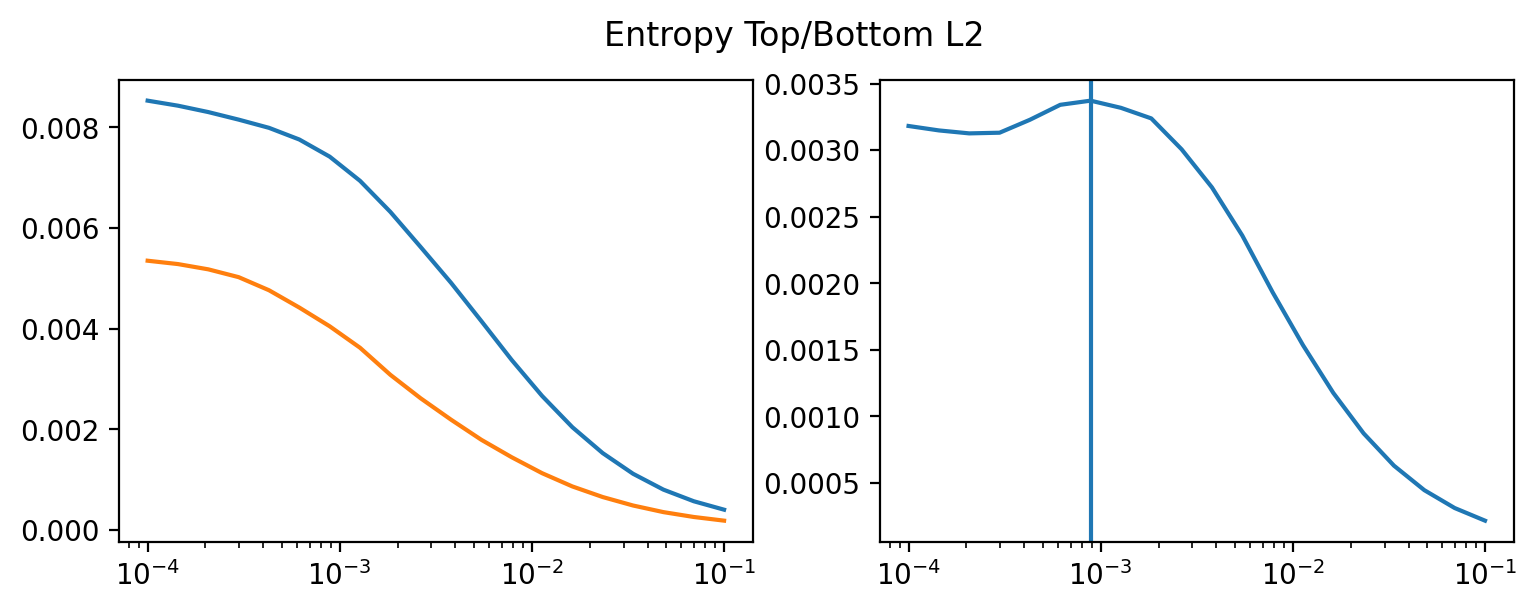

In [2212]:
idx_max, kappa_optim, pseudo_eps = plot_snr(group_mean_l2s_df, 'entropy_tb_l2')
plt.suptitle("Entropy Top/Bottom L2")
plt.axvline(kappa_optim)

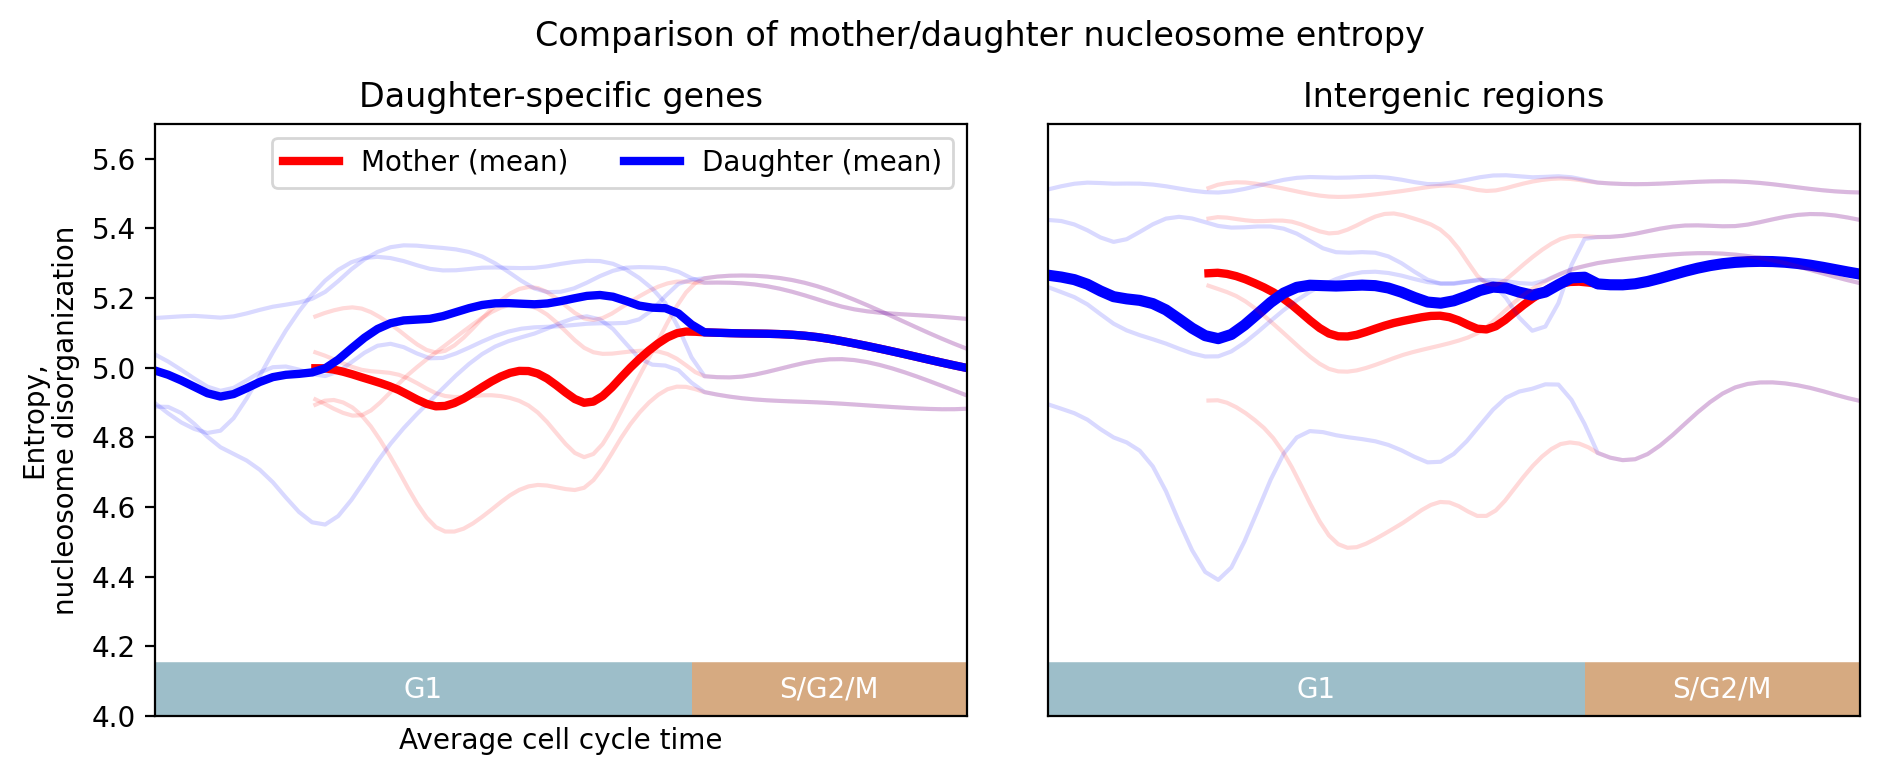

In [2445]:
from src.find_optimal_kappa_chromatin import plot_top_bottom_curves

kappa = kappas[idx_max]#kappa_optim
kappa = kappa.round(5)
plot_top_bottom_curves(config1, kappa, meta_df, entropies_df)
plt.suptitle("Comparison of mother/daughter nucleosome entropy")
plt.subplots_adjust(top=0.85, wspace=0.1)

In [2220]:
selected_rows_df = meta_df.reset_index()
selected_rows_df.kappa = selected_rows_df.kappa.round(5)
selected_rows_df = selected_rows_df.set_index(['group', 'kappa', 'name'])
intergenic_rows_df = selected_rows_df.loc['intergenic'].loc[kappa]
gene_rows_df = selected_rows_df.loc['gene'].loc[kappa]

In [2222]:
from src.find_optimal_kappa_chromatin import plot_summed_rows

In [2399]:
from src.find_optimal_kappa_chromatin import load_intergenic_chromatin_F_from_sweep_run,\
    load_gene_chromatin_F_from_sweep_run

In [2423]:
# interg_name = '4_620908'
# interg_F_imgs, interg_chrom, interg_mnase_span = load_intergenic_chromatin_F_from_sweep_run(
#     config1, meta_df, interg_name, kappa, window)

In [2551]:
import glob

gene_expression_dir = 'output/gene_expression_trial_daughter_comparison/'
expression_paths = glob.glob(f'{gene_expression_dir}/*_F.npy')
plot_dir = 'output/chromatin_kappa.00089_more_genes_intergenics/plots'
mkdir_safe(plot_dir)

for path in expression_paths:
    filepath_spl = path.split('/')[-1].split('_')
    gene_name = filepath_spl[0]
    expression_f = np.load(path)
    
    orfname = get_orfname(gene_name)
    if orfname not in genes.index.values: 
        print("Not in chromatin set. Skipping ", gene_name)
        continue

    gene_F_imgs, gene_chrom, gene_mnase_span = load_gene_chromatin_F_from_sweep_run(config1,
        meta_df, gene_name, kappa, window)

    from src.expression_chromatin_plots import DeconvolutionChromatinExpressionPlotter

    plotter = DeconvolutionChromatinExpressionPlotter(config1)
    plotter.set_chrom_span(gene_chrom, gene_mnase_span)
    plotter.set_expression_data(expression_f)
    plotter.set_chromatin_data(gene_F_imgs)

    fig = plotter.plot()
    
    savepath = f"{plot_dir}/{gene_name}.png"
    plt.savefig(savepath, dpi=150)
    plt.close(fig)
    print("Saved to", savepath)


Creating directory: output/chromatin_kappa.00089_more_genes_intergenics/plots...Directory exists. Skipping.
Saved to output/chromatin_kappa.00089_more_genes_intergenics/plots/DSE3.png
Not in chromatin set. Skipping  RPL1A
Saved to output/chromatin_kappa.00089_more_genes_intergenics/plots/MCM6.png
Saved to output/chromatin_kappa.00089_more_genes_intergenics/plots/CLB2.png
Saved to output/chromatin_kappa.00089_more_genes_intergenics/plots/RPL2A.png
Saved to output/chromatin_kappa.00089_more_genes_intergenics/plots/DSE2.png
Saved to output/chromatin_kappa.00089_more_genes_intergenics/plots/CDC45.png
Saved to output/chromatin_kappa.00089_more_genes_intergenics/plots/RPL2B.png
Saved to output/chromatin_kappa.00089_more_genes_intergenics/plots/CLN2.png
Saved to output/chromatin_kappa.00089_more_genes_intergenics/plots/DSE1.png
Saved to output/chromatin_kappa.00089_more_genes_intergenics/plots/DSE4.png
Saved to output/chromatin_kappa.00089_more_genes_intergenics/plots/RPL1B.png


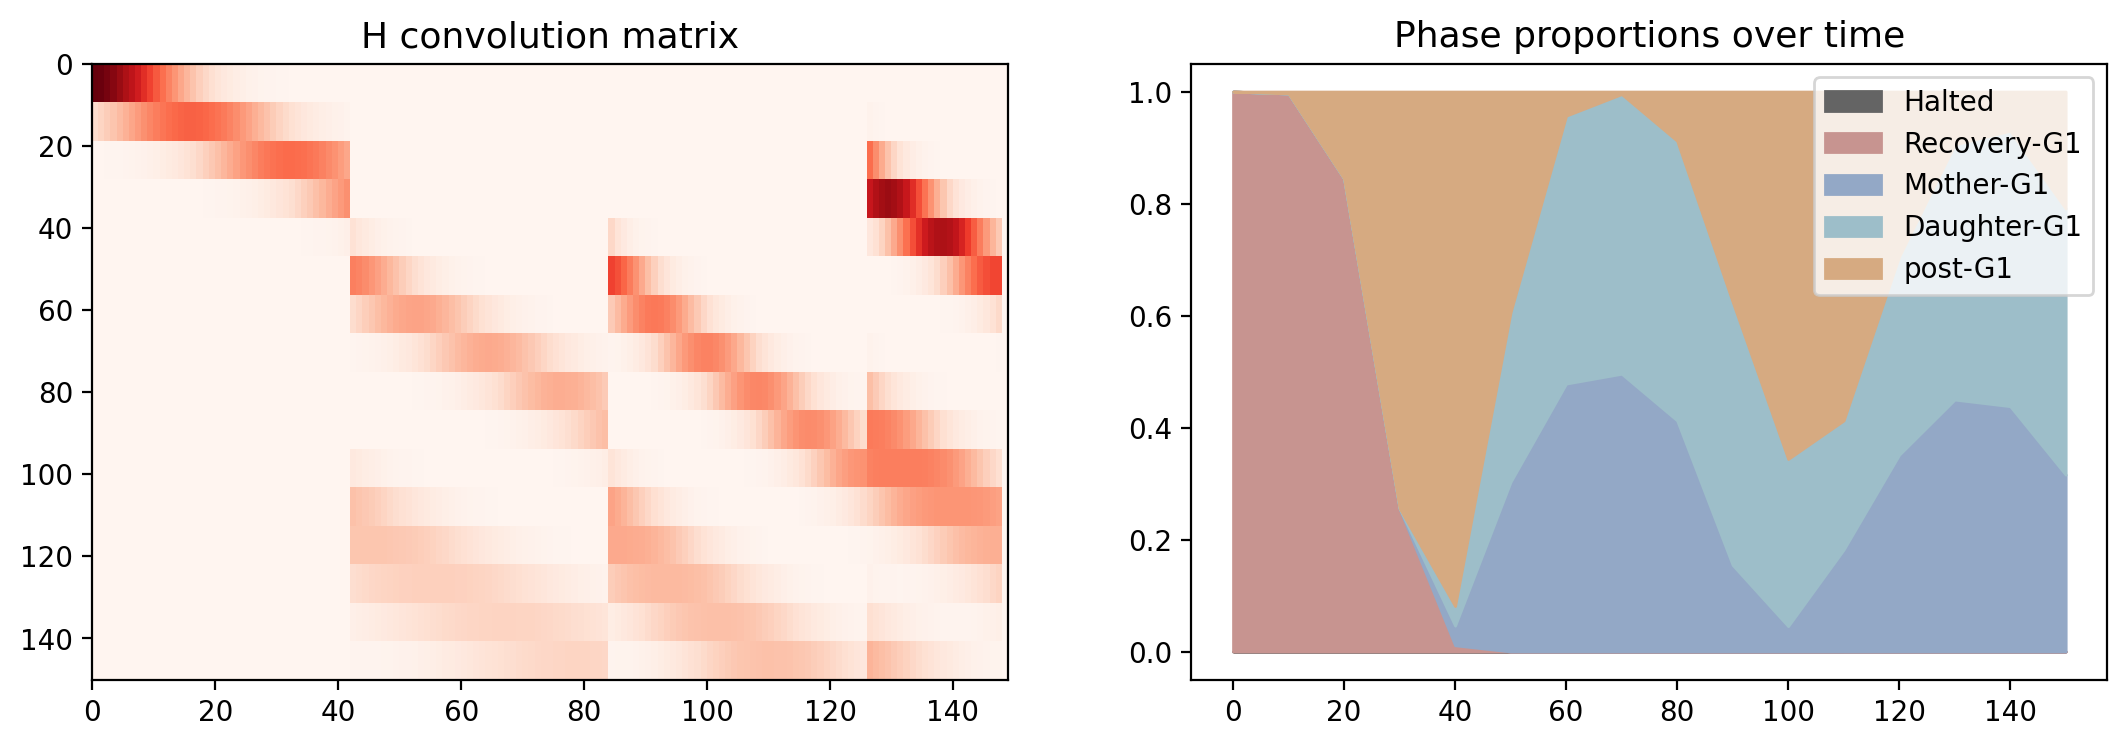

Text(0.5, 1.0, 'Mass of cells in G1')

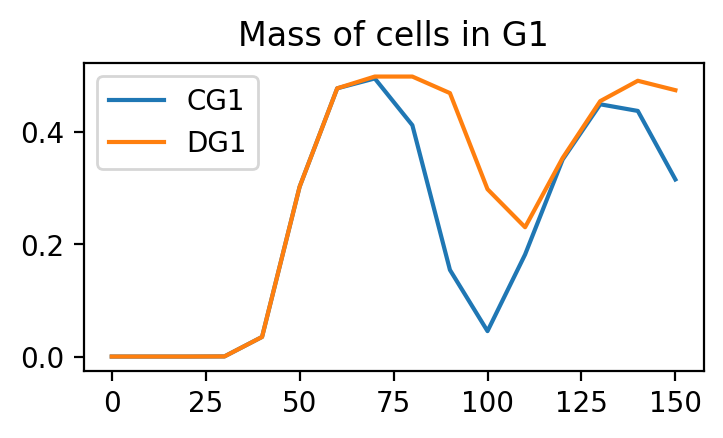

In [2614]:
config1.plot_H()
c_indices = config1.get_Hpositions_for_phase('CG1')
d_indices = config1.get_Hpositions_for_phase('DG1')
plt.show()

plt.figure(figsize=(4, 2))
plt.plot(config1.timepoints, config1.H[:, c_indices].sum(axis=1), label="CG1")
plt.plot(config1.timepoints, config1.H[:, d_indices].sum(axis=1), label="DG1")
plt.legend()
plt.title("Mass of cells in G1")


In [2590]:
from src.sgd import get_orfname
from src.sgd import read_nondubious_genes_dataset

genes = read_nondubious_genes_dataset()
orfname = get_orfname('CLB2')

gene = genes.loc[orfname]
tss = gene.TSS
chrom = gene.chr
mnase_span = tss-100, tss+100

chromatin_model = ChromatinModel(config1)
chromatin_model.load_mnase_span(chrom=chrom, mnase_span=mnase_span)


Loading chromosome reads: 16
Applying a normalization for length distribution


In [2591]:
from src.chromatin_deconvolution_solver import dummy_N_frep_b, \
    subset_select_highest_G_indices

N, frep, b = dummy_N_frep_b(config1)
G_values, highest_Gs = subset_select_highest_G_indices(chromatin_model.G)
chromatin_solver = ChromatinDeconvolveSolver(config1, G_values, N, b, frep)


In [2628]:
c_tps = config1.get_timepoints_for_phase('CG1')
d_tps = config1.get_timepoints_for_phase('DG1')

cg1_tp_length = c_tps[-1]-c_tps[0]
dg1_tp_length = d_tps[-1]-d_tps[0]

dg1_tp_length / cg1_tp_length

1.4118150421275961

0/5 - 00:00:00.438


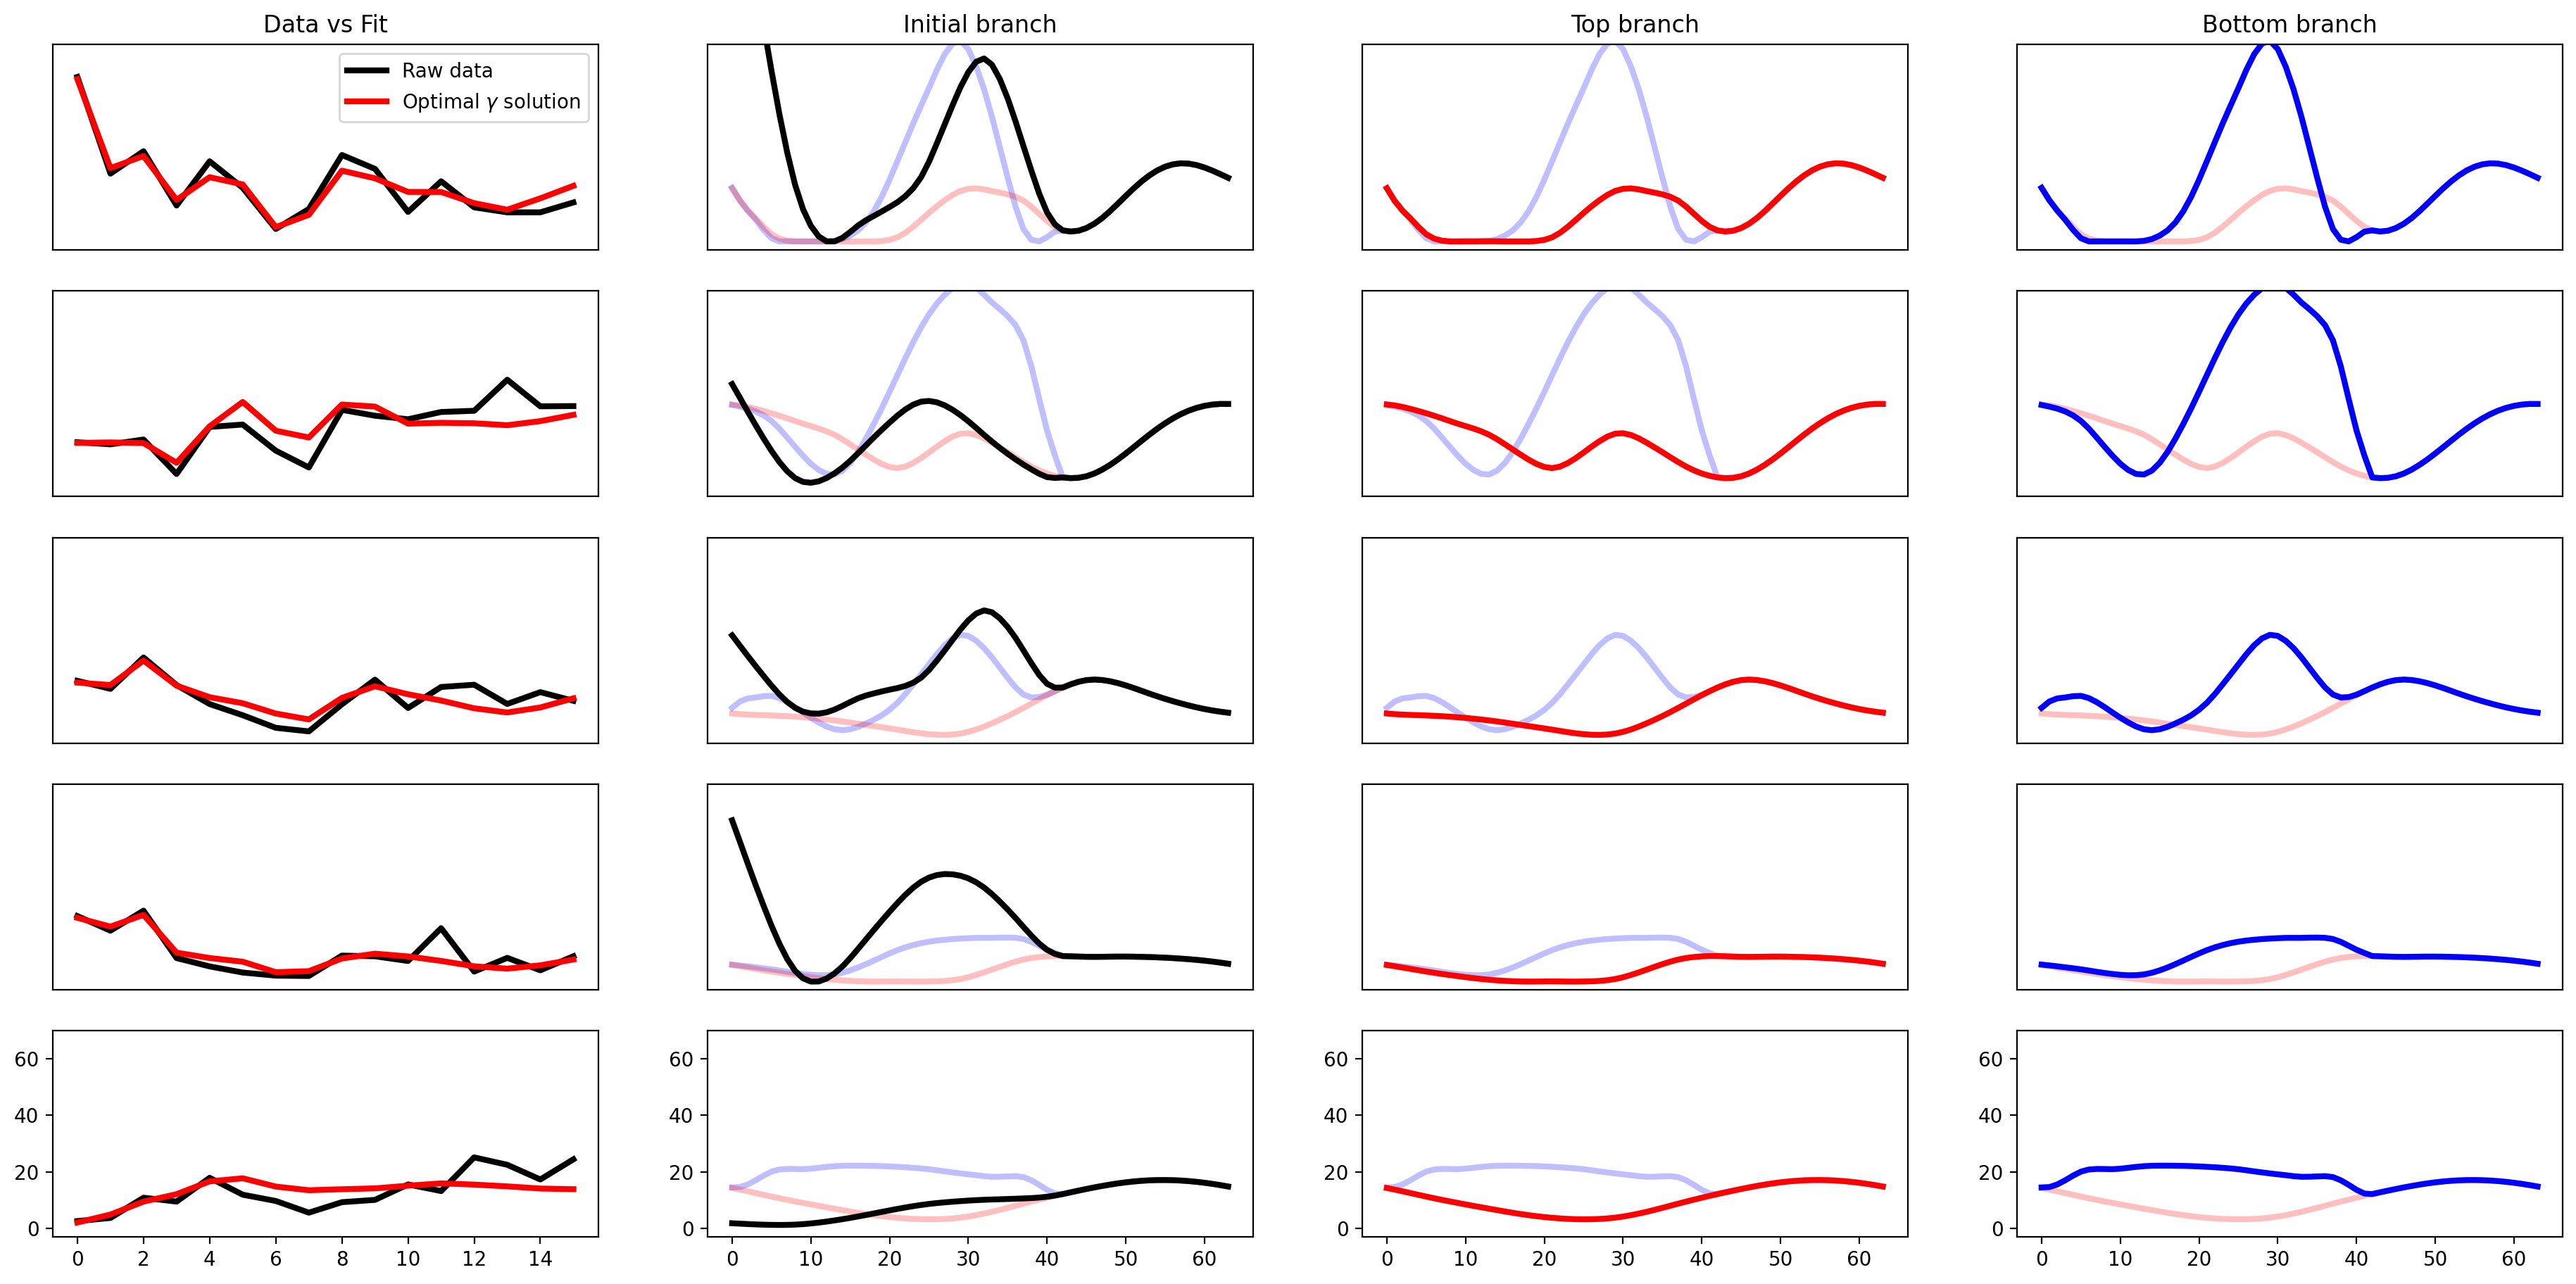

In [2688]:
F_dg1_test = chromatin_solver.deconvolve_G_iteratively(gamma=0.0076, kappa=0.0)
fig = plot_example_fits(chromatin_solver)

0/5 - 00:00:00.341


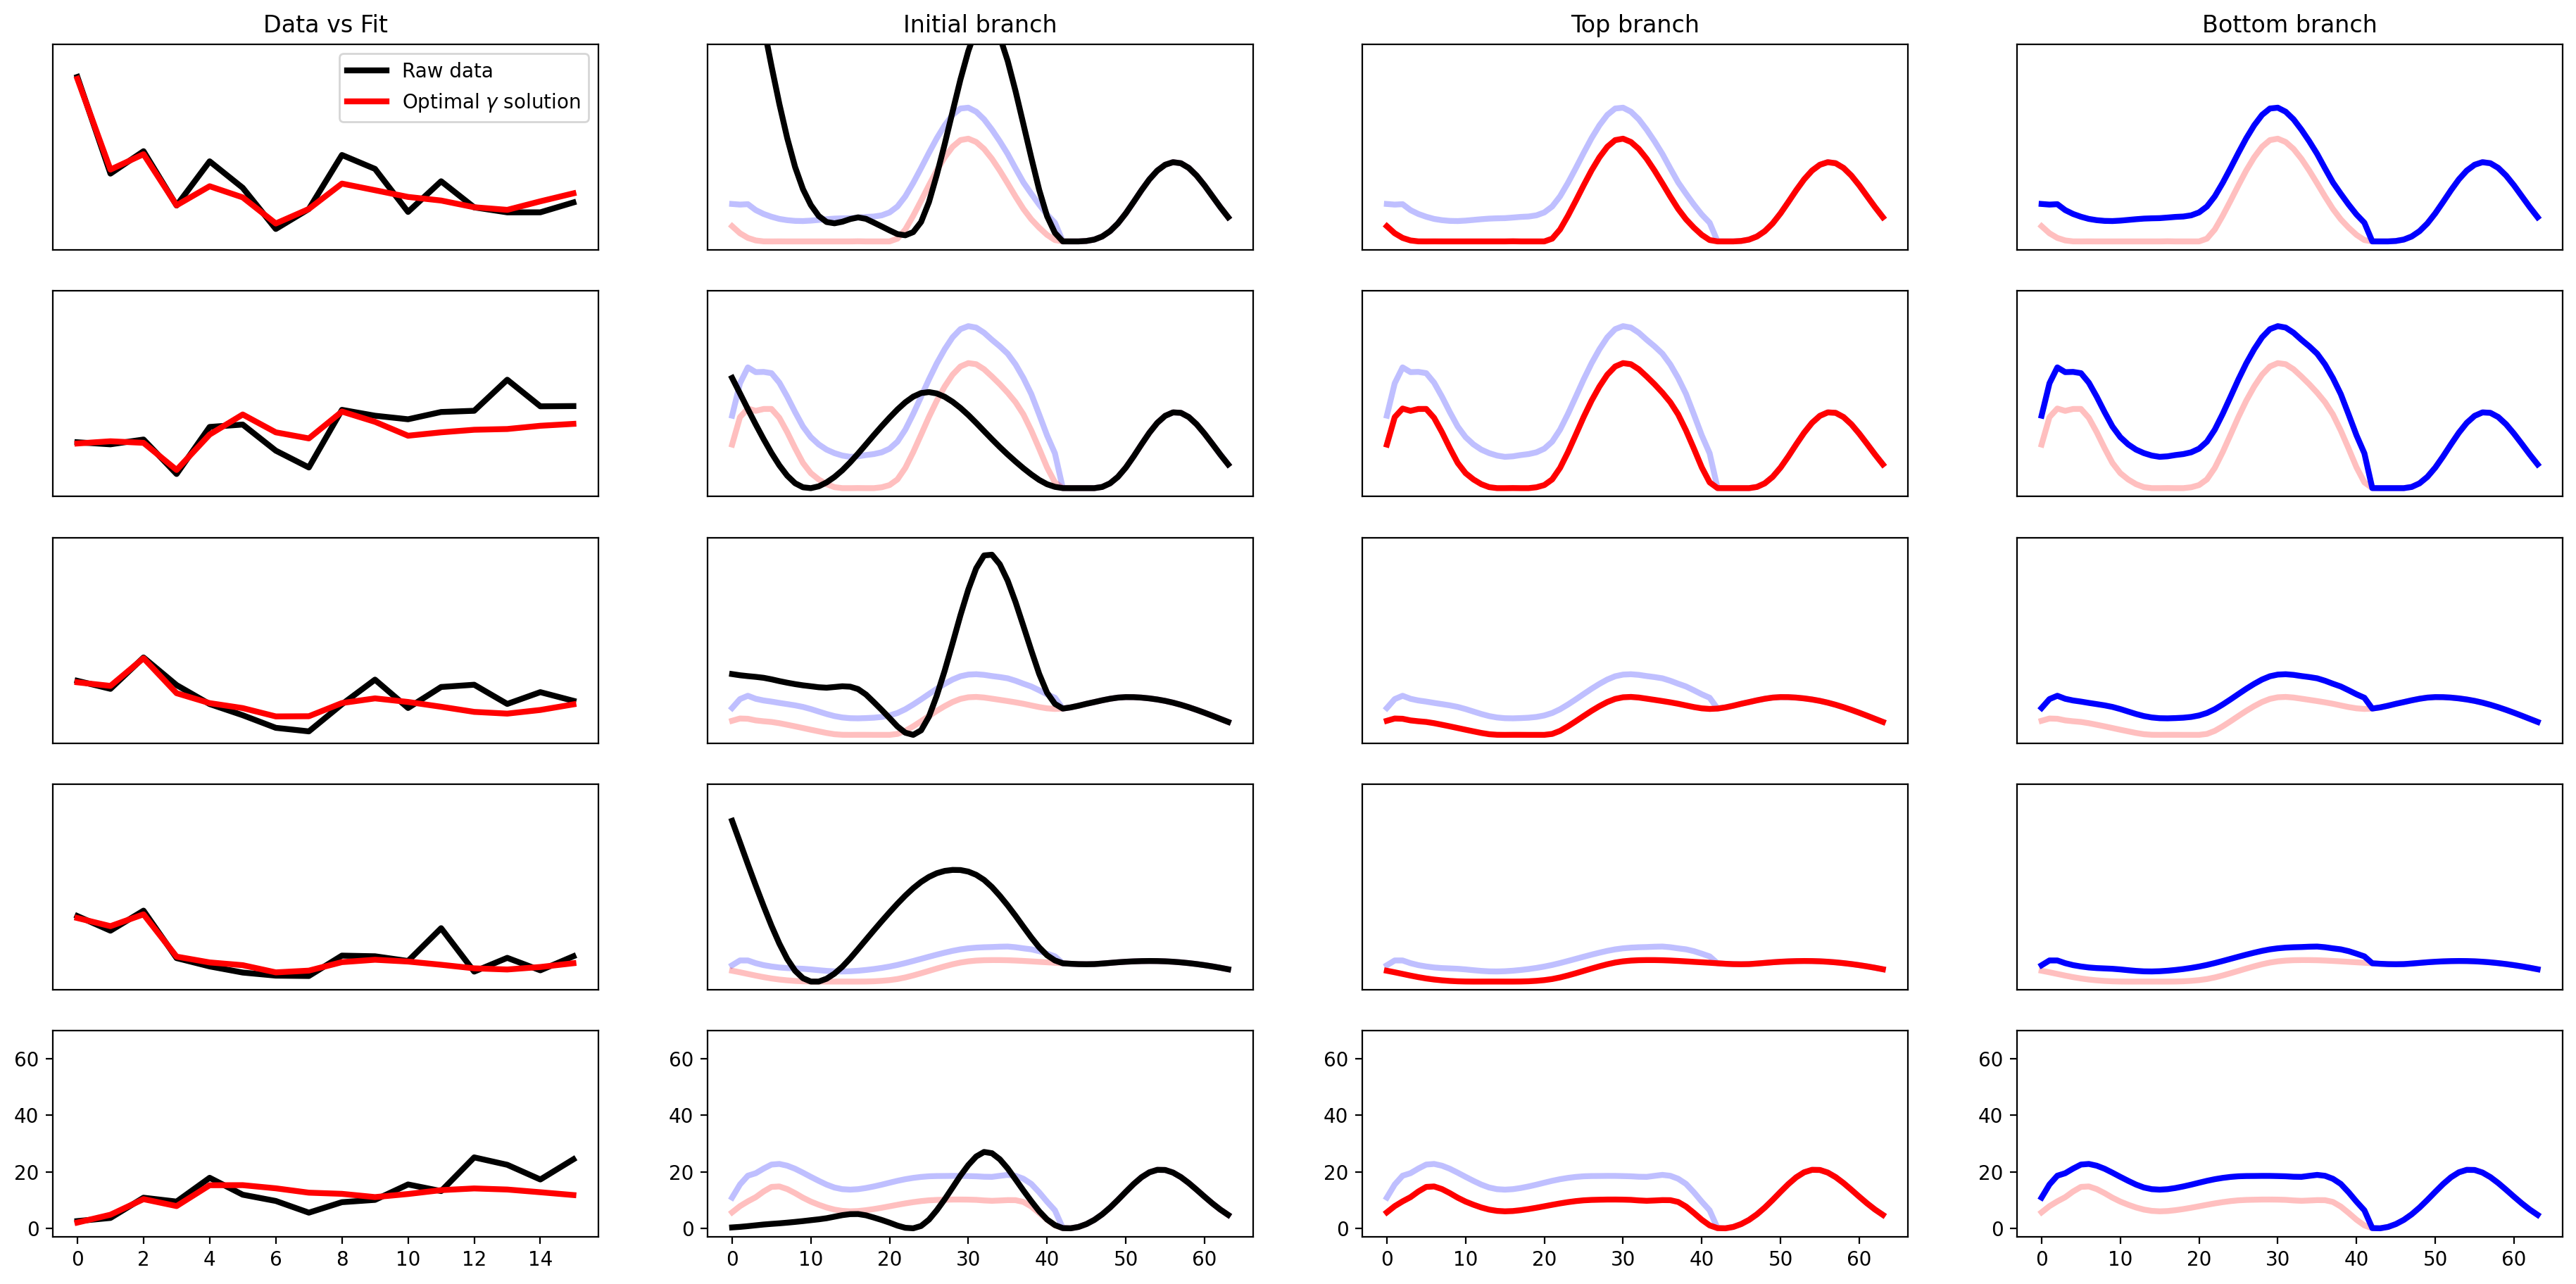

In [2689]:
F_dg1_test = chromatin_solver.deconvolve_G_iteratively(gamma=0.0076, kappa=0.1)
fig = plot_example_fits(chromatin_solver)

0/5 - 00:00:00.274


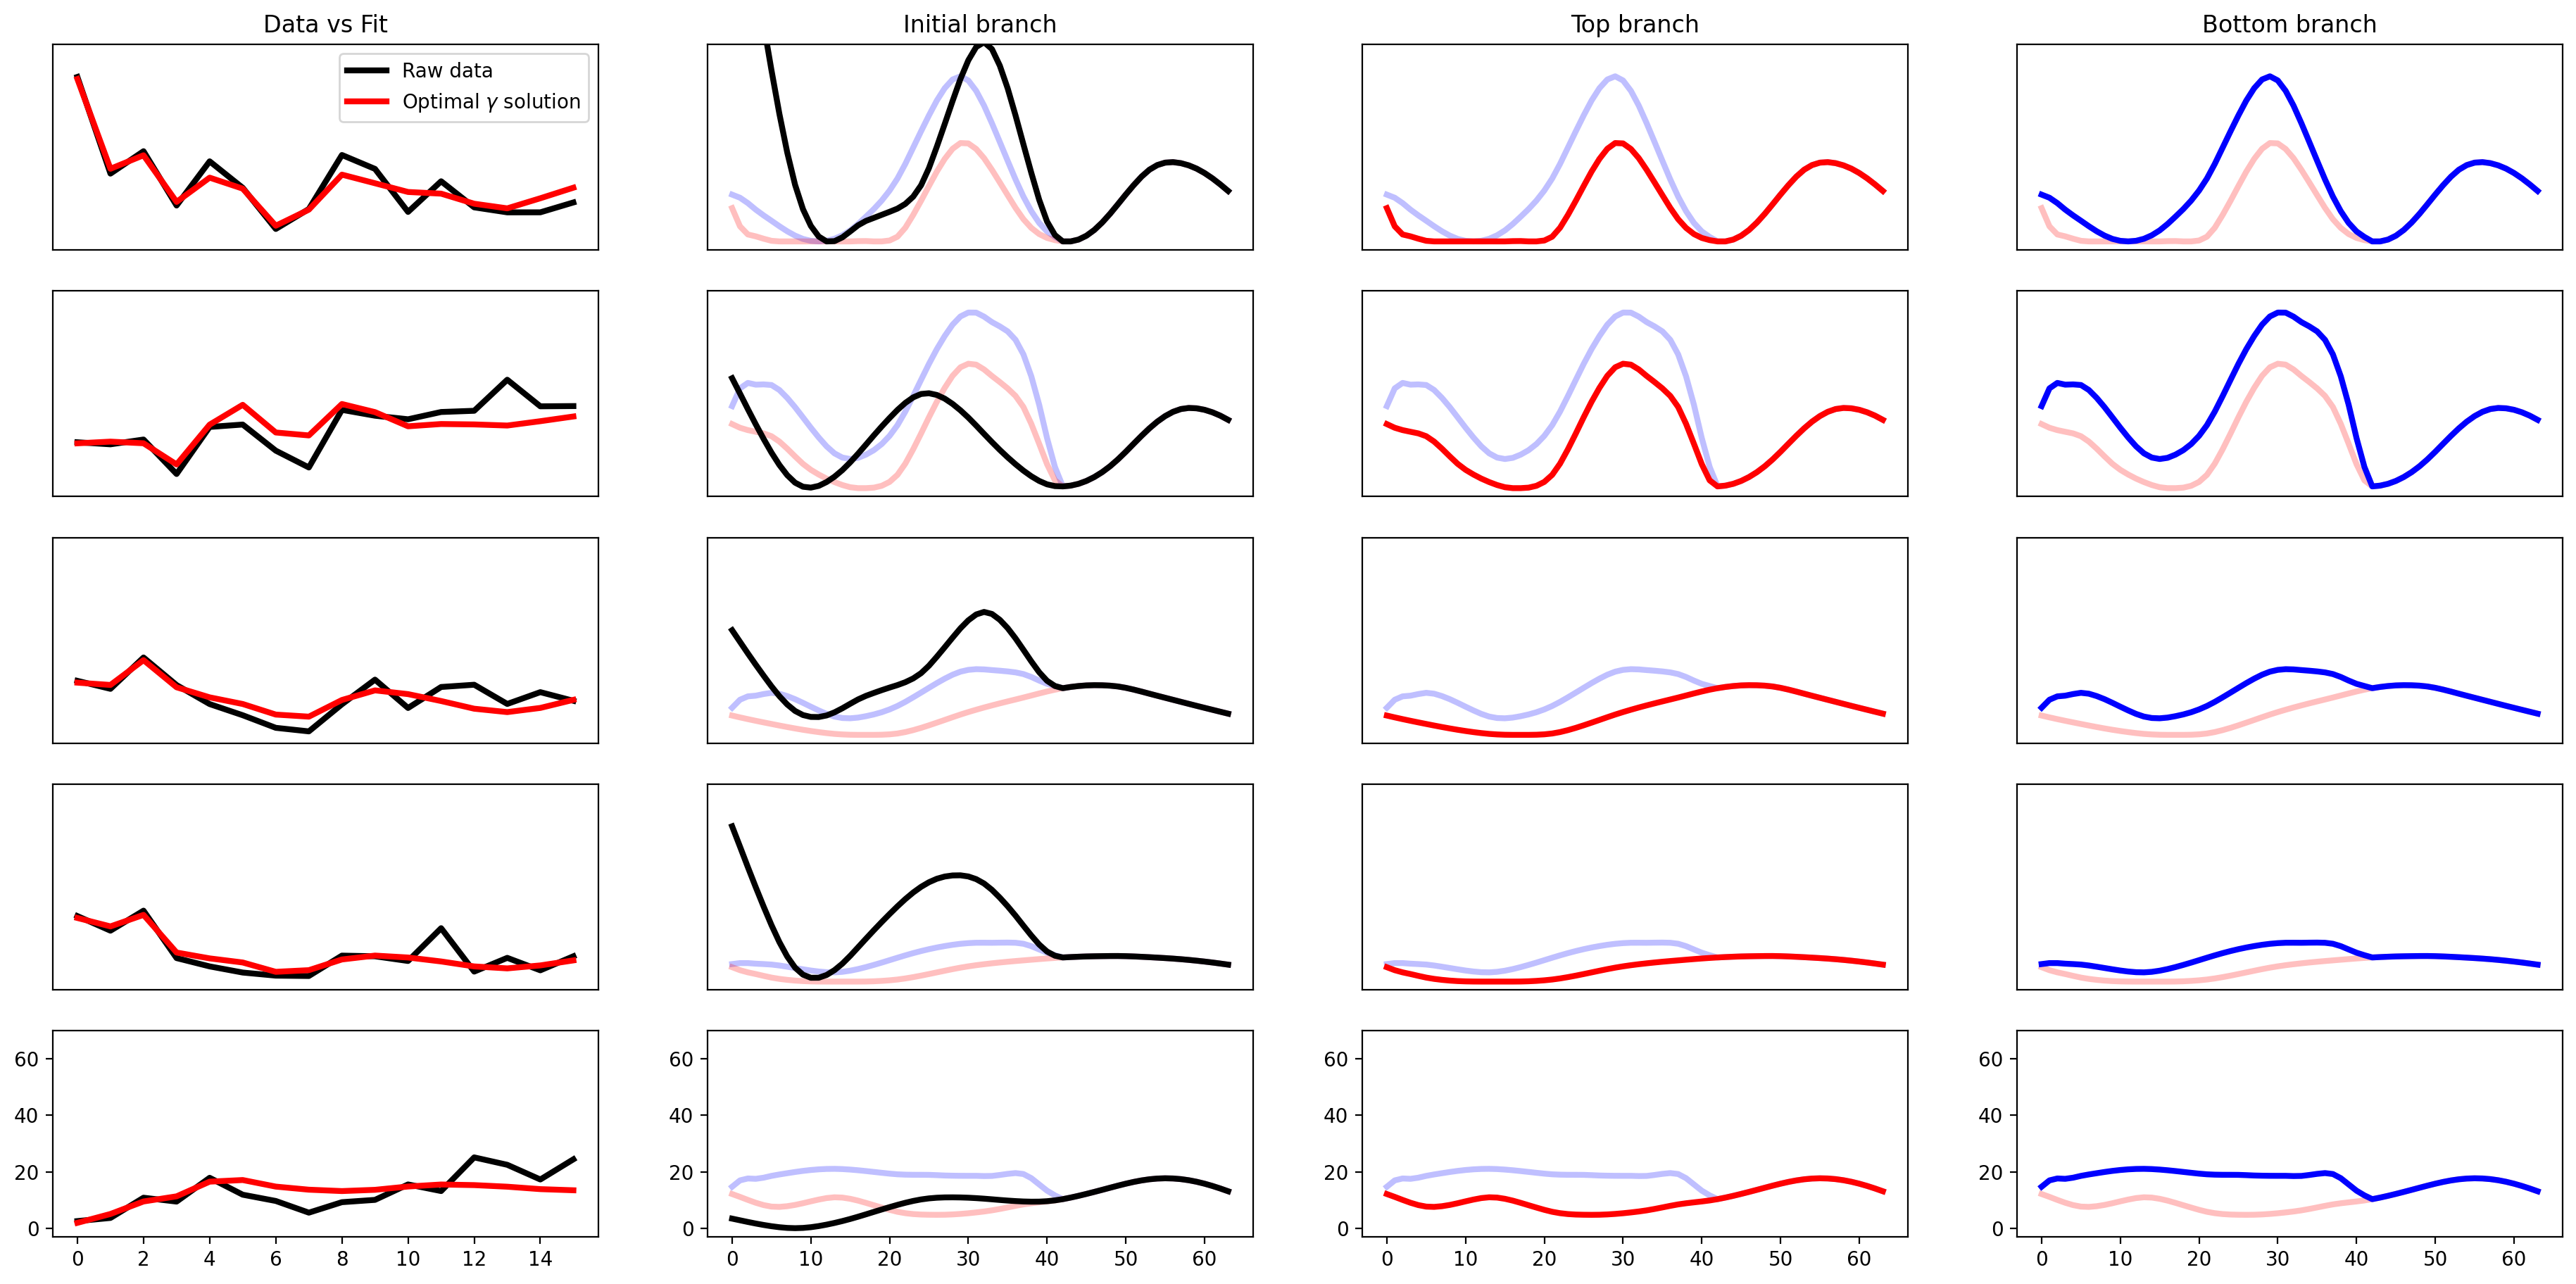

In [2690]:
F_dg1_test = chromatin_solver.deconvolve_G_iteratively(gamma=0.0076, kappa=0.01)
fig = plot_example_fits(chromatin_solver)

0/5 - 00:00:00.312


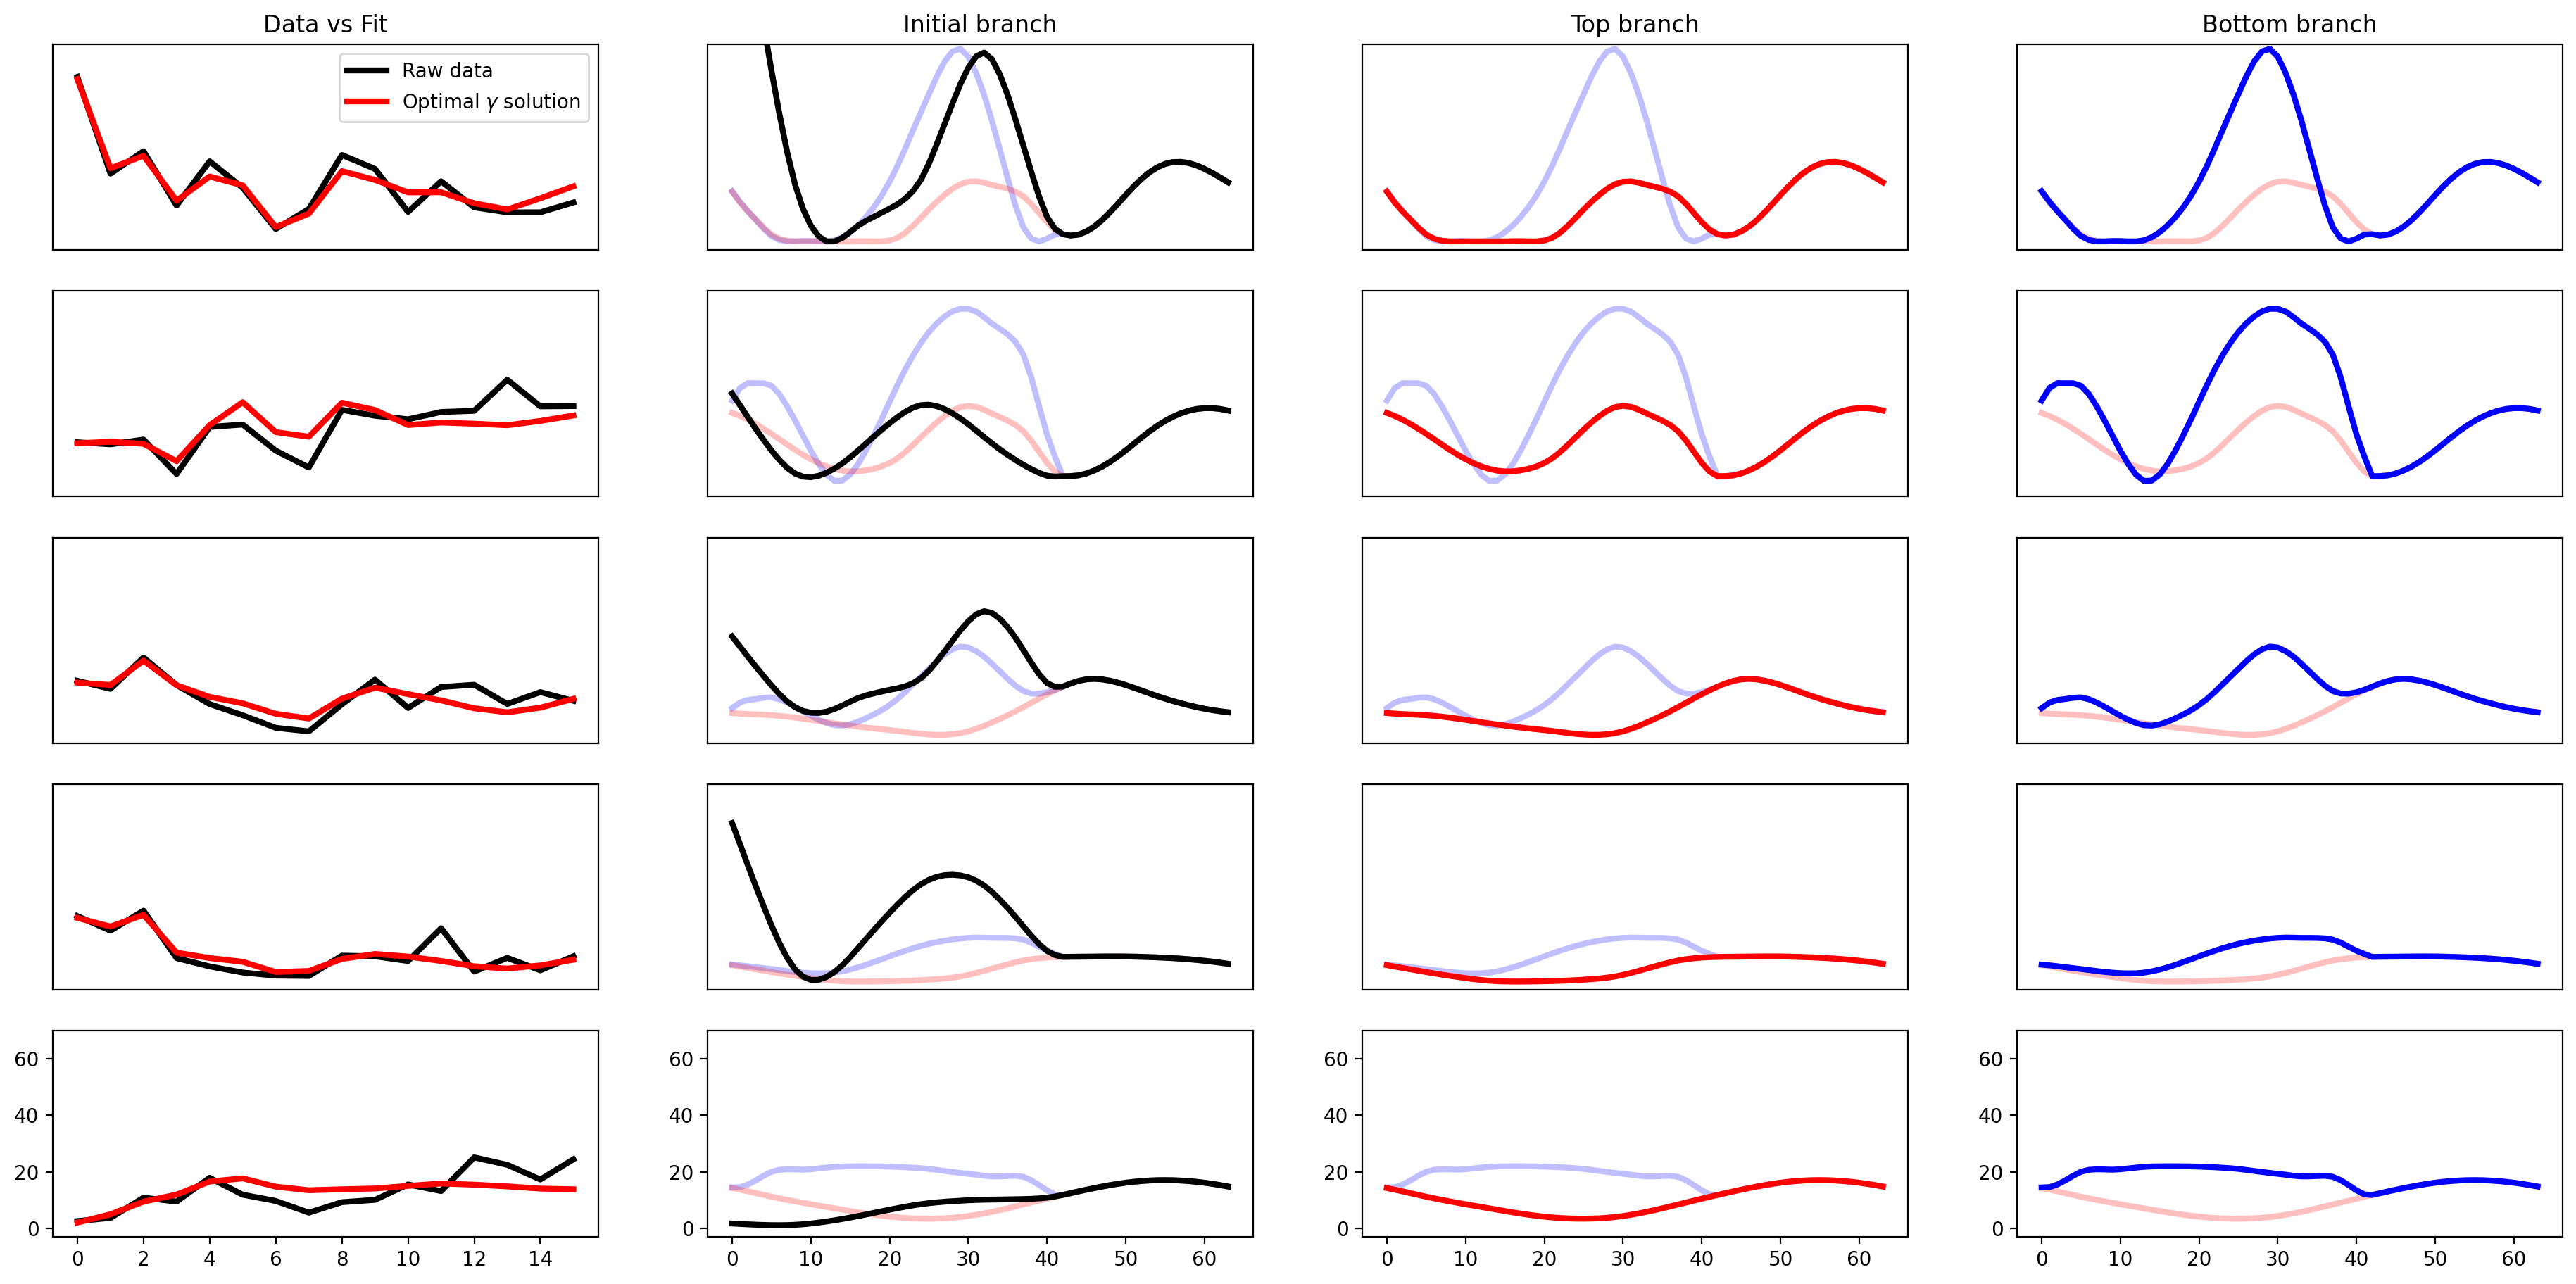

In [2691]:
F_dg1_test = chromatin_solver.deconvolve_G_iteratively(gamma=0.0076, kappa=0.001)
fig = plot_example_fits(chromatin_solver)

0/5 - 00:00:00.211


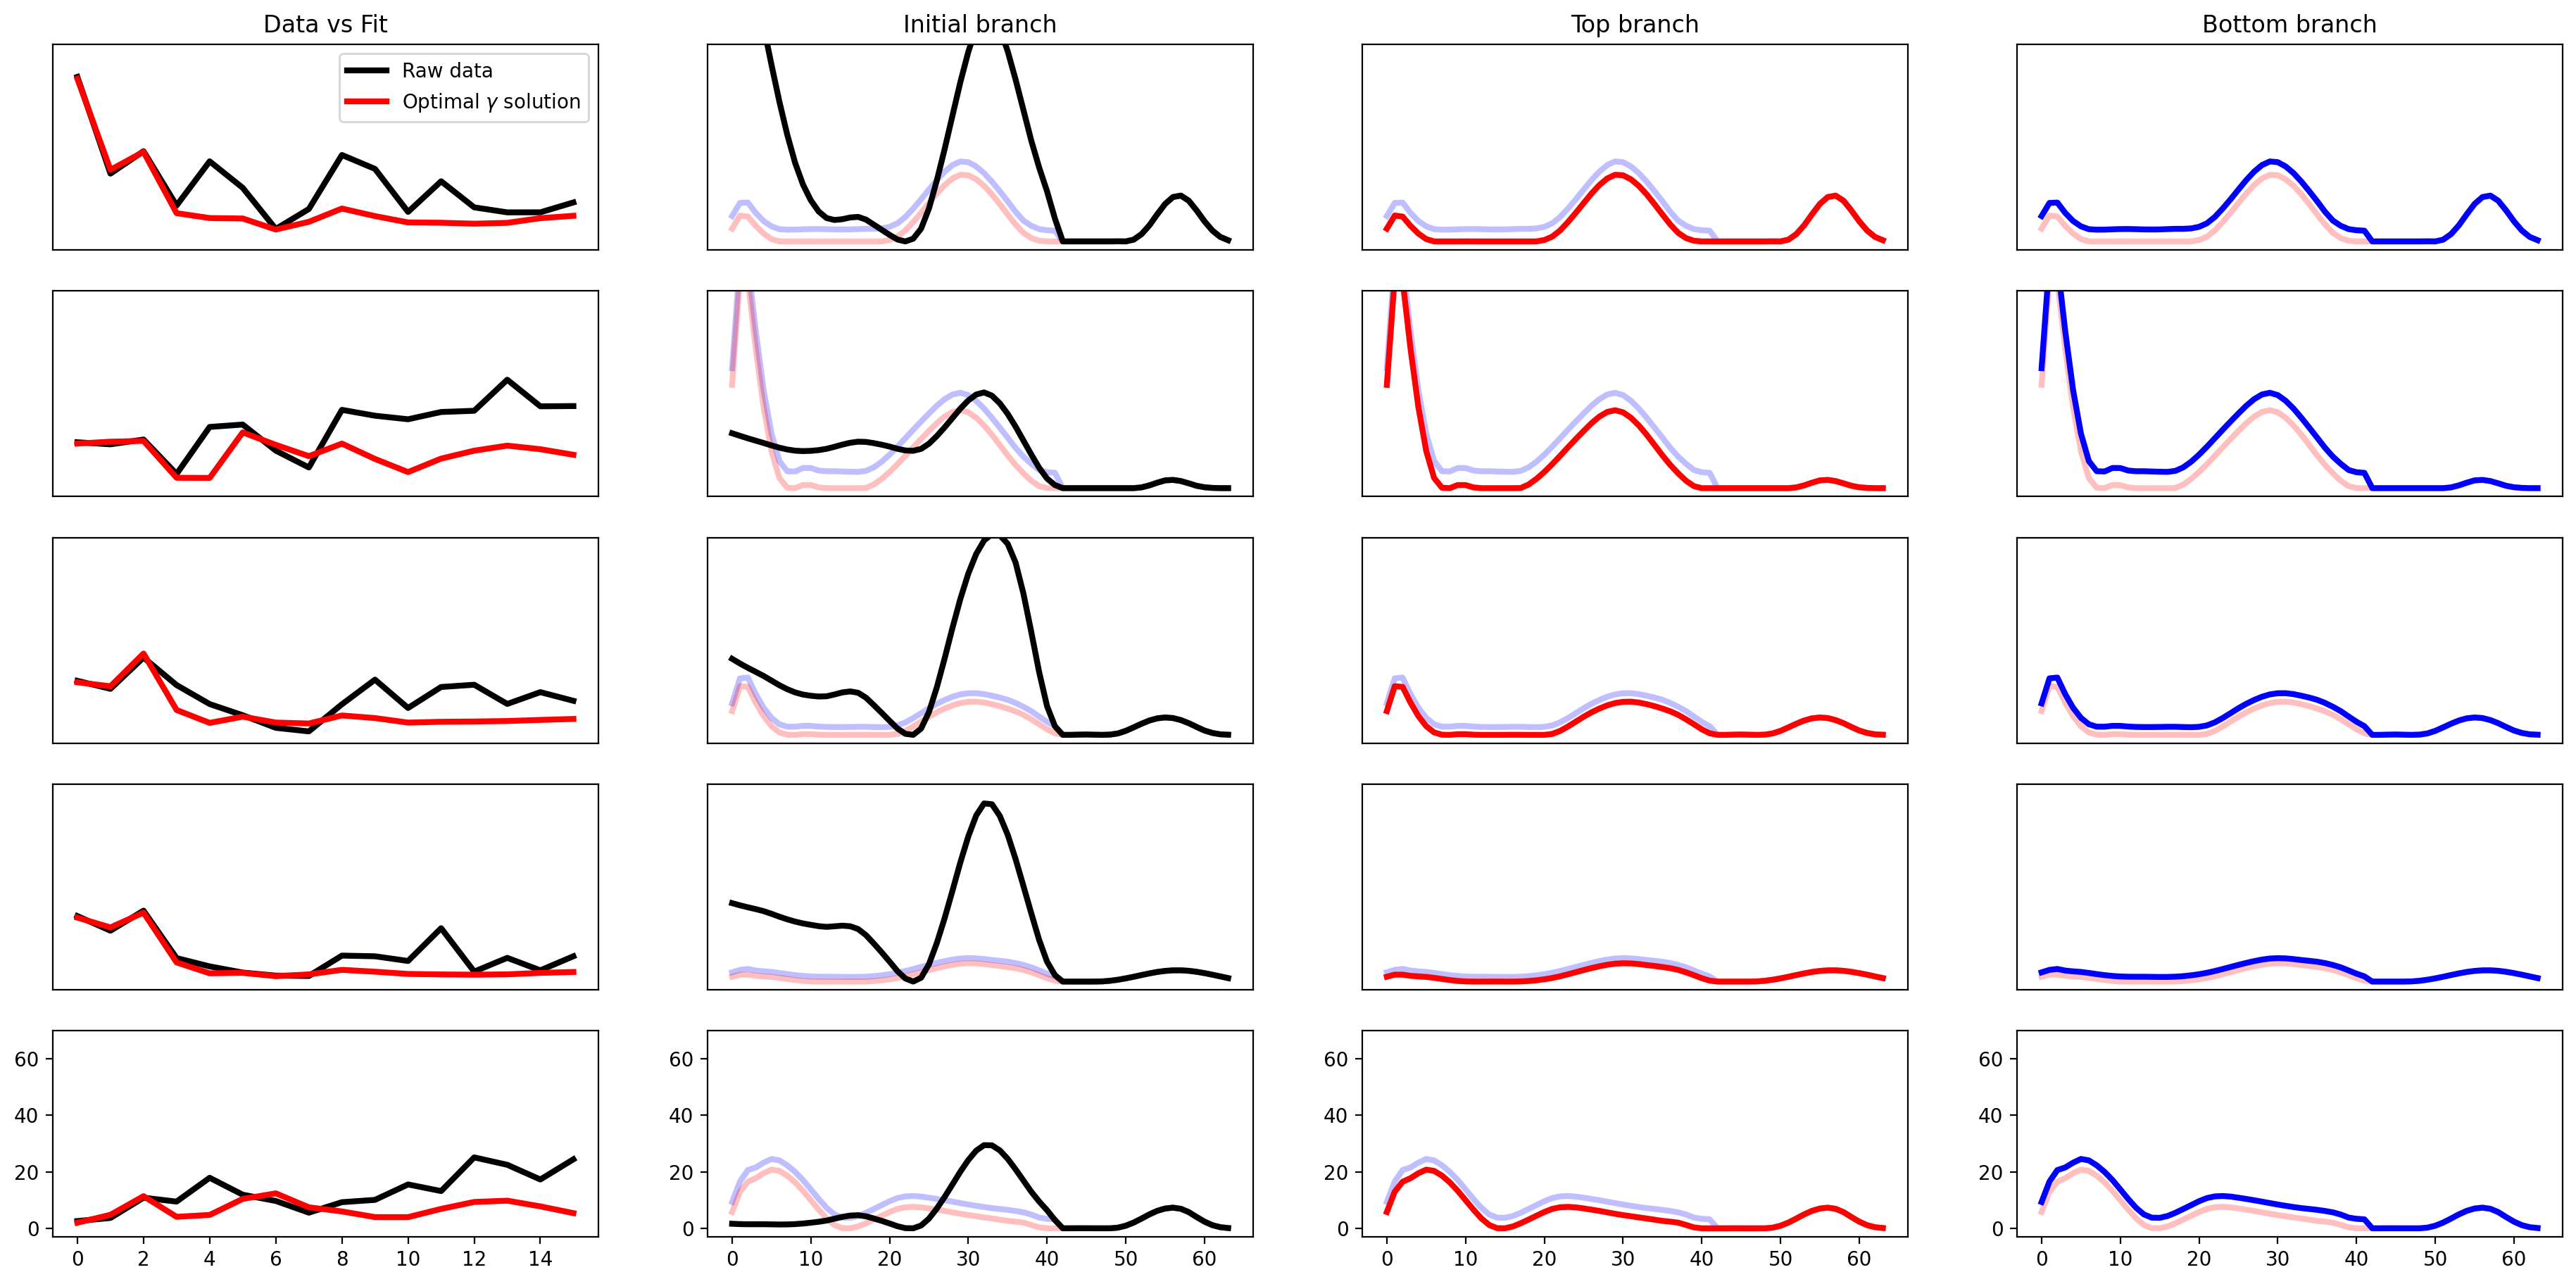

In [2692]:
F_dg1_test = chromatin_solver.deconvolve_G_iteratively(gamma=0.0076, kappa=1.0)
fig = plot_example_fits(chromatin_solver)